In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cat.1714.jpg
/kaggle/input/cat.10025.jpg
/kaggle/input/dog.3113.jpg
/kaggle/input/cat.10782.jpg
/kaggle/input/cat.776.jpg
/kaggle/input/824.jpg
/kaggle/input/456.jpg
/kaggle/input/dog.2753.jpg
/kaggle/input/1528.jpg
/kaggle/input/cat.3041.jpg
/kaggle/input/dog.10802.jpg
/kaggle/input/dog.10470.jpg
/kaggle/input/dog.4118.jpg
/kaggle/input/dog.1646.jpg
/kaggle/input/cat.2601.jpg
/kaggle/input/dog.9098.jpg
/kaggle/input/dog.5758.jpg
/kaggle/input/dog.11230.jpg
/kaggle/input/cat.317.jpg
/kaggle/input/cat.11204.jpg
/kaggle/input/dog.2495.jpg
/kaggle/input/dog.789.jpg
/kaggle/input/790.jpg
/kaggle/input/dog.2332.jpg
/kaggle/input/1149.jpg
/kaggle/input/cat.10836.jpg
/kaggle/input/cat.10444.jpg
/kaggle/input/cat.4859.jpg
/kaggle/input/cat.1375.jpg
/kaggle/input/dog.3572.jpg
/kaggle/input/dog.3900.jpg
/kaggle/input/cat.2260.jpg
/kaggle/input/dog.5339.jpg
/kaggle/input/cat.7299.jpg
/kaggle/input/cat.3852.jpg
/kaggle/input/cat.3420.jpg
/kaggle/input/dog.1580.jpg
/kaggle/input/cat.3

## モジュールのインポート

In [2]:
import os, glob, copy, zipfile
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.utils.data as data
import torch.nn.functional as F
from torchvision import models, transforms

## パラメータ設定

In [3]:
mean = (0.485, 0.456, 0.406) #ImageNetデータセットの平均値
std = (0.229, 0.224, 0.225)  #ImageNetデータセットの標準偏差
batch_size = 32  #バッチサイズ
lr = 0.001  #学習率
epochs = 3#エポック数(この値を小さくすると実行時間を短縮できます)

## データの用意

In [4]:
# データを初期化
!rm -rf ../data

rm: cannot remove '../data/train/train': Device or resource busy
rm: cannot remove '../data/test/test': Device or resource busy
rm: WARNING: Circular directory structure.
This almost certainly means that you have a corrupted file system.
NOTIFY YOUR SYSTEM MANAGER.
The following directory is part of the cycle:
  ../data/dogs-vs-cats-redux-kernels-edition



In [5]:
# zipファイルのディレクトリ
dir_zip = '../input/dogs-vs-cats-redux-kernels-edition'
# データを格納するディレクトリを作成
os.makedirs('../data', exist_ok=True)

# 学習データのzipファイルを展開
with zipfile.ZipFile(os.path.join(dir_zip, 'train.zip')) as train_zip:
    train_zip.extractall('../data')
    
# 推論データのzipファイルを展開
with zipfile.ZipFile(os.path.join(dir_zip, 'test.zip')) as test_zip:
    test_zip.extractall('../data')

# 展開されたディレクトリから画像データのリストを作成
train_list = glob.glob(os.path.join('../data/train', '*.jpg'))
test_list = glob.glob(os.path.join('../data/test', '*.jpg'))

# 学習データから検証データを分割(8:2)
train_list, val_list = train_test_split(train_list, test_size=0.2)

print(f'Train Data:{len(train_list)}')
print(f'Validation Data:{len(val_list)}')

FileNotFoundError: [Errno 2] No such file or directory: '../input/dogs-vs-cats-redux-kernels-edition/train.zip'

In [6]:
# データの前処理の機能

# 学習データ（画像サイズ変換、ランダム反転、テンソル変換、正規化）
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# 推論データ（画像サイズ変換、テンソル変換、正規化）
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [7]:
# 画像データにラベル(0,1)を付ける機能

class CatDogDataset(data.Dataset):
    # 初期化
    def __init__(self, file_list, transform=None):
        self.file_list = file_list
        self.transform = transform
    
    # データセットのサイズ
    def __len__(self):
        return len(self.file_list)
    
    # ラベル付け
    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)
        img_transformed = self.transform(img)
        
        # ファイル名からラベルを取得
        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog': #ファイル名がdogであれば 1
            label = 1
        elif label == 'cat':#ファイル名がcatであれば 0
            label = 0

        return img_transformed, label

In [8]:
# データの前処理
train_dataset = CatDogDataset(train_list, transform=train_transforms)
val_dataset = CatDogDataset(val_list, transform=val_transforms)

# データの読み込み
train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

NameError: name 'train_list' is not defined

## モデルの用意

In [9]:
# ResNet-18の事前学習済みモデル
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
    
# モデルの全結合層を追加して2クラス分類に変更
num_classes = 2
model.fc = nn.Linear(model.fc.in_features, num_classes)

# パラメータを更新する/固定する層を決定
update_params = 'layer4'  #更新したい層の名前（タプルで複数指定しても可）
for name, param in model.named_parameters():
    if name.startswith(update_params):
        param.requires_grad = True
    else:
        param.requires_grad = False

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 損失関数
criterion = nn.CrossEntropyLoss() #クロスエントロピー
# 最適化手法
param_list = list(filter(lambda p: p.requires_grad, model.parameters()))
optimizer = torch.optim.Adam(param_list, lr=lr) #更新する層だけ指定

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 115MB/s]


## 学習

In [10]:
#学習曲線描画のため、ログを取得
train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

# 最良モデルと精度の初期化
best_model = copy.deepcopy(model.state_dict())
best_accuracy = 0.0

# 学習
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    epoch_accuracy = 0

    for data, label in tqdm(train_loader):
        
        data = data.to(device)
        label = label.to(device)

        output = model(data)
        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = (output.argmax(dim=1) == label).float().mean()
        epoch_accuracy  += acc
        epoch_loss      += loss.item()
    epoch_accuracy  /= len(train_loader)
    epoch_loss      /= len(train_loader)

    with torch.no_grad():
        model.eval()
        epoch_val_accuracy = 0
        epoch_val_loss = 0

        for data, label in val_loader:
            data = data.to(device)
            label = label.to(device)

            val_output = model(data)
            val_loss = criterion(val_output, label)

            acc = (val_output.argmax(dim=1) == label).float().mean()
            epoch_val_accuracy  += acc
            epoch_val_loss      += val_loss.item()
        epoch_val_accuracy  /= len(val_loader)
        epoch_val_loss      /= len(val_loader)
    
    print(
        f"Epoch : {epoch+1} - loss : {epoch_loss:.4f} - acc: {epoch_accuracy:.4f} - val_loss : {epoch_val_loss:.4f} - val_acc: {epoch_val_accuracy:.4f}\n"
    )
    # 精度が最も良いならモデルを保存
    if epoch_val_accuracy > best_accuracy:
        best_accuracy = epoch_val_accuracy
        best_model = copy.deepcopy(model.state_dict())

    train_acc_list.append(epoch_accuracy)
    val_acc_list.append(epoch_val_accuracy)
    train_loss_list.append(epoch_loss)
    val_loss_list.append(epoch_val_loss)

torch.save(best_model, '../working/model.pth')

NameError: name 'train_loader' is not defined

## 推論

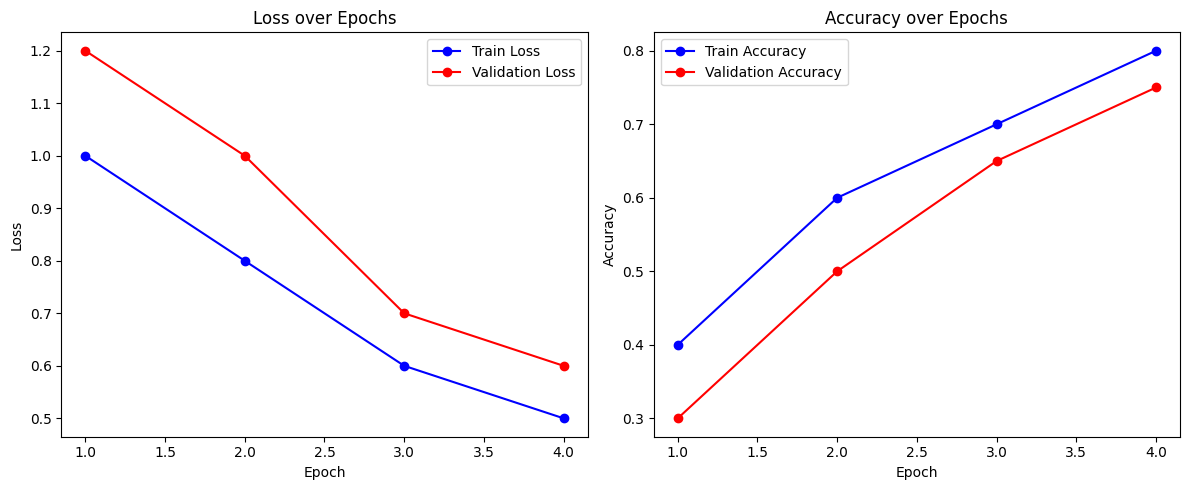

In [11]:
import torch
import matplotlib.pyplot as plt

# 仮の学習データを定義（Tensorのリスト）
# 本番では、ここを学習ループから得られる実データに置き換えてください
train_loss_list = [torch.tensor(1.0), torch.tensor(0.8), torch.tensor(0.6), torch.tensor(0.5)]
val_loss_list = [torch.tensor(1.2), torch.tensor(1.0), torch.tensor(0.7), torch.tensor(0.6)]
train_acc_list = [torch.tensor(0.4), torch.tensor(0.6), torch.tensor(0.7), torch.tensor(0.8)]
val_acc_list = [torch.tensor(0.3), torch.tensor(0.5), torch.tensor(0.65), torch.tensor(0.75)]

# Tensor → NumPy へ変換（CPU上のテンソル前提）
train_loss_np = [t.cpu().numpy() for t in train_loss_list]
val_loss_np = [t.cpu().numpy() for t in val_loss_list]
train_acc_np = [t.cpu().numpy() for t in train_acc_list]
val_acc_np = [t.cpu().numpy() for t in val_acc_list]

# エポック数
epochs = range(1, len(train_loss_np) + 1)

# グラフ描画
plt.figure(figsize=(12, 5))

# Loss の描画
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_np, 'bo-', label='Train Loss')
plt.plot(epochs, val_loss_np, 'ro-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Accuracy の描画
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_np, 'bo-', label='Train Accuracy')
plt.plot(epochs, val_acc_np, 'ro-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
param = torch.load('../working/model.pth')
model.load_state_dict(param)
model = model.eval()

# IDと予測値の格納用リスト
id_list = []
pred_list = []

with torch.no_grad():
    for test_path in tqdm(test_list):
        # 画像とIDの取得
        img = Image.open(test_path)
        id_number = int(test_path.split('/')[-1].split('.')[0])
        
        # 推論用に画像データを変換
        img = val_transforms(img)
        img = img.unsqueeze(0)
        img = img.to(device)

        outputs = model(img)
        preds = F.softmax(outputs, dim=1)[:, 1].tolist() #dogの確率

        # IDと予測値をリストに追加
        id_list.append(id_number)
        pred_list.append(preds[0])

FileNotFoundError: [Errno 2] No such file or directory: '../working/model.pth'

## 提出用csvファイルの作成

In [13]:
# サンプルファイルを利用
submit = pd.read_csv(dir_zip + '/sample_submission.csv')

submit.set_index('id', inplace=True)
submit.loc[id_list, 'label'] = pred_list
submit.reset_index(inplace=True)

submit.to_csv('/kaggle/working/submission.csv', index=False)

FileNotFoundError: [Errno 2] No such file or directory: '../input/dogs-vs-cats-redux-kernels-edition/sample_submission.csv'

In [14]:
print(submit)

NameError: name 'submit' is not defined

In [15]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  